# LightEval CSD Batch-Size Sweep Analysis

This notebook analyzes the output from `benchmark/csd/eval/run_lighteval_csd_batchsize_sweep.sh`.

The launch script loops over `BATCH_SIZES`, `NUM_RUNS`, `SPEC_SHAPES`, `MODES`, and `CSD_DYNAMIC_UPDATES`. Each result row is one LightEval task from one suite run. The notebook parses those loop values from `run_tag`, averages repeated runs by configuration, and plots throughput plus speculative success rate against max batch size.

In [12]:
from pathlib import Path
import json
import math
import re

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, StrMethodFormatter

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 220)
pd.set_option('display.max_colwidth', 140)

RESULT_JSONL = Path('/home/zhouxuwen/sglang/benchmark/csd/runs/lighteval_batchsize_sweep/20260509_175911/results/result.jsonl')
assert RESULT_JSONL.exists(), RESULT_JSONL
FIGURE_DIR = RESULT_JSONL.parent / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR

PosixPath('/home/zhouxuwen/sglang/benchmark/csd/runs/lighteval_batchsize_sweep/20260509_175911/results/figures')

## Load and flatten rows

In [13]:
def base_task_name(task):
    if not isinstance(task, str):
        return task
    return task.split('|', 1)[0]

def parse_run_tag(run_tag):
    if not isinstance(run_tag, str):
        return {}
    pattern = re.compile(
        r'_bs(?P<batch_size>\d+)'
        r'_rep(?P<repeat_idx>\d+)'
        r'_(?P<shape_name>[^_]+)'
        r'_steps(?P<steps>\d+)'
        r'_topk(?P<topk>\d+)'
        r'_draft(?P<draft>\d+)'
        r'_freq(?P<freq>\d+)'
        r'_ratio(?P<ratio>[0-9.]+)'
        r'(?P<dynamic>_dynamic)?$'
    )
    match = pattern.search(run_tag)
    if not match:
        return {}
    values = match.groupdict()
    return {
        'tag_batch_size': int(values['batch_size']),
        'repeat_idx': int(values['repeat_idx']),
        'shape_name': values['shape_name'],
        'tag_steps': int(values['steps']),
        'tag_topk': int(values['topk']),
        'tag_draft_tokens': int(values['draft']),
        'tag_freq_threshold': int(values['freq']),
        'tag_prob_ratio': float(values['ratio']),
        'tag_dynamic_update': bool(values['dynamic']),
    }

def spec_shape_label(shape_name, steps, topk, draft):
    if pd.isna(steps) or steps is None:
        return 'baseline'
    prefix = f'{shape_name}: ' if isinstance(shape_name, str) and shape_name else ''
    return f'{prefix}s{int(steps)} / k{int(topk)} / d{int(draft)}'

def config_label(row):
    if row['mode'] == 'vanilla':
        return f"Vanilla | {row['spec_shape']}"
    if row['mode'] == 'csd':
        dyn = 'dyn' if row['csd_dynamic_update'] else 'static'
        return f"CSD {dyn} | {row['spec_shape']}"
    return str(row['mode'])

def flatten_row(row, line_no):
    other = row.get('other') or {}
    speculative = other.get('speculative') or {}
    csd = other.get('csd') or {}
    performance = other.get('performance') or {}
    server_config = other.get('server_config') or {}
    spec_metrics = other.get('speculative_metrics') or {}

    task = row.get('task') or other.get('task')
    mode = other.get('mode')
    run_tag = other.get('run_tag')
    tag_values = parse_run_tag(run_tag)

    steps = speculative.get('num_steps') or tag_values.get('tag_steps')
    topk = speculative.get('eagle_topk') or tag_values.get('tag_topk')
    draft = speculative.get('num_draft_tokens') or tag_values.get('tag_draft_tokens')
    max_running_requests = other.get('max_running_requests') or server_config.get('max_running_requests') or tag_values.get('tag_batch_size')
    shape_name = tag_values.get('shape_name')

    return {
        'line': line_no,
        'task': task,
        'base_task': base_task_name(task),
        'mode': mode,
        'run_tag': run_tag,
        'repeat_idx': tag_values.get('repeat_idx'),
        'shape_name': shape_name,
        'max_running_requests': max_running_requests,
        'tag_batch_size': tag_values.get('tag_batch_size'),
        'spec_steps': steps,
        'spec_topk': topk,
        'spec_draft_tokens': draft,
        'spec_shape': spec_shape_label(shape_name, steps, topk, draft),
        'csd_freq_threshold': csd.get('freq_threshold', tag_values.get('tag_freq_threshold')),
        'csd_prob_ratio': csd.get('prob_ratio', tag_values.get('tag_prob_ratio')),
        'csd_dynamic_update': bool(csd.get('dynamic_update', tag_values.get('tag_dynamic_update', False))),
        'tag_dynamic_update': tag_values.get('tag_dynamic_update'),
        'throughput': row.get('throughput'),
        'request_throughput': performance.get('request_throughput'),
        'total_token_throughput': performance.get('total_token_throughput'),
        'latency_sec': row.get('latency'),
        'accuracy': row.get('accuracy'),
        'spec_success_rate': row.get('spec_success_rate'),
        'avg_spec_success_rate': row.get('avg_spec_success_rate'),
        'aggregate_spec_accept_rate': row.get('aggregate_spec_accept_rate'),
        'accept_length': row.get('accept_length'),
        'aggregate_accept_length': row.get('aggregate_accept_length'),
        'spec_output_token_saved_ratio': row.get('spec_output_token_saved_ratio'),
        'spec_verify_ct': row.get('spec_verify_ct'),
        'spec_draft_token_num': row.get('spec_draft_token_num'),
        'csd_enabled': row.get('csd_enabled'),
        'csd_lookup_hit_ct': row.get('csd_lookup_hit_ct'),
        'csd_forced_accept_ct': row.get('csd_forced_accept_ct'),
        'csd_delta_pair_ct': row.get('csd_delta_pair_ct'),
        'num_requests': row.get('num_requests'),
        'avg_prompt_tokens': row.get('avg_prompt_tokens'),
        'avg_completion_tokens': row.get('avg_completion_tokens'),
        'total_completion_tokens': spec_metrics.get('total_completion_tokens'),
        'model': other.get('model'),
        'max_gen_toks': other.get('max_gen_toks'),
        'max_length': other.get('max_length'),
        'tp_size': server_config.get('tp_size'),
        'mem_fraction_static': server_config.get('mem_fraction_static'),
        'mamba_scheduler_strategy': server_config.get('mamba_scheduler_strategy'),
    }

rows = []
with RESULT_JSONL.open(encoding='utf-8') as f:
    for line_no, line in enumerate(f, 1):
        line = line.strip()
        if line:
            rows.append(flatten_row(json.loads(line), line_no))

df = pd.DataFrame(rows)
df['config_label'] = df.apply(config_label, axis=1)
df['max_running_requests'] = pd.to_numeric(df['max_running_requests'])
print(f'Loaded {len(df)} rows from {RESULT_JSONL}')
df.head()

Loaded 60 rows from /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval_batchsize_sweep/20260509_175911/results/result.jsonl


,line,task,base_task,mode,run_tag,repeat_idx,shape_name,max_running_requests,tag_batch_size,spec_steps,spec_topk,spec_draft_tokens,spec_shape,csd_freq_threshold,csd_prob_ratio,csd_dynamic_update,tag_dynamic_update,throughput,request_throughput,total_token_throughput,latency_sec,accuracy,spec_success_rate,avg_spec_success_rate,aggregate_spec_accept_rate,accept_length,aggregate_accept_length,spec_output_token_saved_ratio,spec_verify_ct,spec_draft_token_num,csd_enabled,csd_lookup_hit_ct,csd_forced_accept_ct,csd_delta_pair_ct,num_requests,avg_prompt_tokens,avg_completion_tokens,total_completion_tokens,model,max_gen_toks,max_length,tp_size,mem_fraction_static,mamba_scheduler_strategy,config_label
0,1,gsm8k|0,gsm8k,vanilla,vanilla_gsm8k-0_tasksgsm8k-aime25_bs8_rep1_tree_steps5_topk3_draft15_freq6_ratio0.3,1,tree,8,8,5,3,15,tree: s5 / k3 / d15,6,0.3,False,False,1588.384,0.909,1657.431,1450.896,0.927976,0.8697,0.8697,0.8697,5.4296,5.3483,0.8132,430900,6032600,False,0,0,0,1319,75.951,1747.218,2304581,/home/shared/models/Qwen/Qwen3.5-35B-A3B,64000,96000,2,0.85,no_buffer,Vanilla | tree: s5 / k3 / d15
1,2,aime25|0,aime25,vanilla,vanilla_aime25-0_tasksgsm8k-aime25_bs8_rep1_tree_steps5_topk3_draft15_freq6_ratio0.3,1,tree,8,8,5,3,15,tree: s5 / k3 / d15,6,0.3,False,False,1100.263,0.040,1110.091,741.576,0.900000,0.7376,0.7376,0.7376,4.7072,4.6879,0.7867,174051,2436714,False,0,0,0,30,242.933,27197.633,815929,/home/shared/models/Qwen/Qwen3.5-35B-A3B,64000,96000,2,0.85,no_buffer,Vanilla | tree: s5 / k3 / d15
2,3,gsm8k|0,gsm8k,csd,csd_gsm8k-0_tasksgsm8k-aime25_bs8_rep1_tree_steps5_topk3_draft15_freq6_ratio0.3,1,tree,8,8,5,3,15,tree: s5 / k3 / d15,6,0.3,False,False,1605.153,0.958,1677.949,1376.163,0.910538,0.8934,0.8934,0.8934,5.5187,5.4669,0.8172,404061,5656854,True,82963450,27176182,0,1319,75.951,1674.717,2208952,/home/shared/models/Qwen/Qwen3.5-35B-A3B,64000,96000,2,0.85,no_buffer,CSD static | tree: s5 / k3 / d15
3,4,aime25|0,aime25,csd,csd_aime25-0_tasksgsm8k-aime25_bs8_rep1_tree_steps5_topk3_draft15_freq6_ratio0.3,1,tree,8,8,5,3,15,tree: s5 / k3 / d15,6,0.3,False,False,1189.166,0.043,1199.712,691.046,0.833333,0.8276,0.8276,0.8276,5.1262,5.1382,0.8054,159934,2239076,True,1463934,789491,0,30,242.933,27392.300,821769,/home/shared/models/Qwen/Qwen3.5-35B-A3B,64000,96000,2,0.85,no_buffer,CSD static | tree: s5 / k3 / d15
4,5,gsm8k|0,gsm8k,csd,csd_gsm8k-0_tasksgsm8k-aime25_bs8_rep1_tree_steps5_topk3_draft15_freq6_ratio0.3_dynamic,1,tree,8,8,5,3,15,tree: s5 / k3 / d15,6,0.3,True,True,1412.238,0.830,1475.253,1589.761,0.921911,0.9021,0.9021,0.9021,5.5493,5.5105,0.8187,407424,5703936,True,101315743,33746527,218296089,1319,75.951,1702.139,2245121,/home/shared/models/Qwen/Qwen3.5-35B-A3B,64000,96000,2,0.85,no_buffer,CSD dyn | tree: s5 / k3 / d15


## Sweep dimensions and repeat counts

Repeat counts are computed with the same dimensions as the script loop: dataset, mode, spec shape, CSD dynamic flag, and `max_running_requests`. If `NUM_RUNS > 1`, every configuration should have that many rows before averaging.

## Script-derived sweep summary

The script uses `NUM_RUNS` for repeated measurements. `RUN_REPEAT` is only copied into the generated run id by `suite_run_id`; it is not the loop count. Therefore `rep1` in this result file means `repeat_idx=1`, not three repeated measurements.

In [14]:
script_summary = pd.DataFrame([
    ('BATCH_SIZES', ' '.join(map(str, sorted(df['max_running_requests'].dropna().unique())))),
    ('NUM_RUNS observed', int(df['repeat_idx'].nunique()) if df['repeat_idx'].notna().any() else None),
    ('repeat_idx values', ', '.join(map(str, sorted(df['repeat_idx'].dropna().astype(int).unique())))),
    ('MODES', ' '.join(map(str, sorted(df['mode'].dropna().unique())))),
    ('SPEC_SHAPES', ' | '.join(df[['shape_name', 'spec_steps', 'spec_topk', 'spec_draft_tokens']].drop_duplicates().sort_values(['shape_name', 'spec_topk']).apply(
        lambda row: f"{row['shape_name']}:{int(row['spec_steps'])}:{int(row['spec_topk'])}:{int(row['spec_draft_tokens'])}", axis=1
    ))),
    ('CSD_DYNAMIC_UPDATES observed', ' '.join(map(lambda x: '1' if x else '0', sorted(df.loc[df['mode'] == 'csd', 'csd_dynamic_update'].dropna().unique())))),
    ('TASKS', ' '.join(map(str, sorted(df['base_task'].dropna().unique())))),
    ('CSD_FREQ_THRESHOLD', ' '.join(map(lambda x: f'{x:g}', sorted(df['csd_freq_threshold'].dropna().unique())))),
    ('CSD_PROB_RATIO', ' '.join(map(lambda x: f'{x:g}', sorted(df['csd_prob_ratio'].dropna().unique())))),
], columns=['script field', 'observed value'])

display(script_summary)

,script field,observed value
0,BATCH_SIZES,8 16 32 48 64
1,NUM_RUNS observed,1
2,repeat_idx values,1
3,MODES,csd vanilla
4,SPEC_SHAPES,serial:5:1:5 | tree:5:3:15
5,CSD_DYNAMIC_UPDATES observed,0 1
6,TASKS,aime25 gsm8k
7,CSD_FREQ_THRESHOLD,6
8,CSD_PROB_RATIO,0.3


In [15]:
dimension_cols = [
    'base_task', 'mode', 'spec_shape', 'csd_dynamic_update',
    'csd_freq_threshold', 'csd_prob_ratio', 'max_running_requests',
]
repeat_counts = (
    df.groupby(dimension_cols, dropna=False)
    .agg(
        num_samples=('line', 'size'),
        unique_repeat_ids=('repeat_idx', lambda s: ','.join(map(str, sorted(s.dropna().astype(int).unique())))),
        num_unique_repeat_ids=('repeat_idx', lambda s: s.dropna().nunique()),
    )
    .reset_index()
    .sort_values(['base_task', 'spec_shape', 'mode', 'csd_dynamic_update', 'max_running_requests'])
)

print('Repeat aggregation uses num_samples, so duplicate repeat_idx values are still averaged together.')
display(df.groupby(['base_task', 'mode', 'spec_shape', 'csd_dynamic_update'], dropna=False).size().rename('rows').reset_index())
display(repeat_counts)

duplicate_repeat_ids = repeat_counts[repeat_counts['num_samples'] > repeat_counts['num_unique_repeat_ids']]
if not duplicate_repeat_ids.empty:
    print('Note: some configurations have duplicate repeat_idx values. They are included as independent samples in the mean:')
    display(duplicate_repeat_ids)

print('num_samples distribution by configuration:')
display(repeat_counts['num_samples'].value_counts().sort_index().rename_axis('num_samples').reset_index(name='configs'))

Repeat aggregation uses num_samples, so duplicate repeat_idx values are still averaged together.


,base_task,mode,spec_shape,csd_dynamic_update,rows
0,aime25,csd,serial: s5 / k1 / d5,False,5
1,aime25,csd,serial: s5 / k1 / d5,True,5
2,aime25,csd,tree: s5 / k3 / d15,False,5
3,aime25,csd,tree: s5 / k3 / d15,True,5
4,aime25,vanilla,serial: s5 / k1 / d5,False,5
5,aime25,vanilla,tree: s5 / k3 / d15,False,5
6,gsm8k,csd,serial: s5 / k1 / d5,False,5
7,gsm8k,csd,serial: s5 / k1 / d5,True,5
8,gsm8k,csd,tree: s5 / k3 / d15,False,5
9,gsm8k,csd,tree: s5 / k3 / d15,True,5


,base_task,mode,spec_shape,csd_dynamic_update,csd_freq_threshold,csd_prob_ratio,max_running_requests,num_samples,unique_repeat_ids,num_unique_repeat_ids
0,aime25,csd,serial: s5 / k1 / d5,False,6,0.3,8,1,1,1
1,aime25,csd,serial: s5 / k1 / d5,False,6,0.3,16,1,1,1
2,aime25,csd,serial: s5 / k1 / d5,False,6,0.3,32,1,1,1
3,aime25,csd,serial: s5 / k1 / d5,False,6,0.3,48,1,1,1
4,aime25,csd,serial: s5 / k1 / d5,False,6,0.3,64,1,1,1
5,aime25,csd,serial: s5 / k1 / d5,True,6,0.3,8,1,1,1
6,aime25,csd,serial: s5 / k1 / d5,True,6,0.3,16,1,1,1
7,aime25,csd,serial: s5 / k1 / d5,True,6,0.3,32,1,1,1
8,aime25,csd,serial: s5 / k1 / d5,True,6,0.3,48,1,1,1
9,aime25,csd,serial: s5 / k1 / d5,True,6,0.3,64,1,1,1


num_samples distribution by configuration:


,num_samples,configs
0,1,60


## Average repeated runs

Rows are averaged by dataset, decoding configuration, and `max_running_requests`. Standard deviations are kept for throughput and speculative success rate so the plots can show uncertainty when repeat runs are present.

In [16]:
group_cols = [
    'base_task', 'mode', 'config_label', 'shape_name', 'spec_shape',
    'spec_steps', 'spec_topk', 'spec_draft_tokens',
    'csd_freq_threshold', 'csd_prob_ratio', 'csd_dynamic_update',
    'max_running_requests',
]

avg_df = (
    df.groupby(group_cols, dropna=False)
    .agg(
        num_samples=('line', 'size'),
        repeat_ids=('repeat_idx', lambda s: ','.join(map(str, sorted(s.dropna().astype(int).unique())))),
        first_line=('line', 'min'),
        throughput_mean=('throughput', 'mean'),
        throughput_std=('throughput', 'std'),
        request_throughput_mean=('request_throughput', 'mean'),
        total_token_throughput_mean=('total_token_throughput', 'mean'),
        spec_success_rate_mean=('spec_success_rate', 'mean'),
        spec_success_rate_std=('spec_success_rate', 'std'),
        latency_sec_mean=('latency_sec', 'mean'),
        accuracy_mean=('accuracy', 'mean'),
        accuracy_std=('accuracy', 'std'),
        accept_length_mean=('accept_length', 'mean'),
        aggregate_spec_accept_rate_mean=('aggregate_spec_accept_rate', 'mean'),
        spec_output_token_saved_ratio_mean=('spec_output_token_saved_ratio', 'mean'),
    )
    .reset_index()
    .sort_values(['base_task', 'spec_shape', 'mode', 'csd_dynamic_update', 'max_running_requests'])
)
avg_df[['throughput_std', 'spec_success_rate_std', 'accuracy_std']] = avg_df[['throughput_std', 'spec_success_rate_std', 'accuracy_std']].fillna(0.0)

display(avg_df.style.format({
    'throughput_mean': '{:.1f}',
    'throughput_std': '{:.1f}',
    'request_throughput_mean': '{:.3f}',
    'total_token_throughput_mean': '{:.1f}',
    'spec_success_rate_mean': '{:.4f}',
    'spec_success_rate_std': '{:.4f}',
    'latency_sec_mean': '{:.1f}',
    'accuracy_mean': '{:.4f}',
    'accuracy_std': '{:.4f}',
    'accept_length_mean': '{:.4f}',
    'aggregate_spec_accept_rate_mean': '{:.4f}',
    'spec_output_token_saved_ratio_mean': '{:.4f}',
}, na_rep=''))

,base_task,mode,config_label,shape_name,spec_shape,spec_steps,spec_topk,spec_draft_tokens,csd_freq_threshold,csd_prob_ratio,csd_dynamic_update,max_running_requests,num_samples,repeat_ids,first_line,throughput_mean,throughput_std,request_throughput_mean,total_token_throughput_mean,spec_success_rate_mean,spec_success_rate_std,latency_sec_mean,accuracy_mean,accuracy_std,accept_length_mean,aggregate_spec_accept_rate_mean,spec_output_token_saved_ratio_mean
10,aime25,csd,CSD static | serial: s5 / k1 / d5,serial,serial: s5 / k1 / d5,5,1,5,6,0.300000,False,8,1,1,10,1617.7,0.0,0.058,1631.8,0.7070,0.0000,517.3,0.8000,0.0000,4.4929,0.7070,0.7795
11,aime25,csd,CSD static | serial: s5 / k1 / d5,serial,serial: s5 / k1 / d5,5,1,5,6,0.300000,False,16,1,1,22,2021.0,0.0,0.067,2037.4,0.6967,0.0000,444.6,0.8333,0.0000,4.4723,0.6967,0.7770
12,aime25,csd,CSD static | serial: s5 / k1 / d5,serial,serial: s5 / k1 / d5,5,1,5,6,0.300000,False,32,1,1,34,2261.9,0.0,0.086,2282.9,0.6964,0.0000,347.1,0.9000,0.0000,4.4712,0.6964,0.7769
13,aime25,csd,CSD static | serial: s5 / k1 / d5,serial,serial: s5 / k1 / d5,5,1,5,6,0.300000,False,48,1,1,46,2261.3,0.0,0.086,2282.3,0.6964,0.0000,347.2,0.9000,0.0000,4.4712,0.6964,0.7769
14,aime25,csd,CSD static | serial: s5 / k1 / d5,serial,serial: s5 / k1 / d5,5,1,5,6,0.300000,False,64,1,1,58,2280.5,0.0,0.087,2301.7,0.6964,0.0000,344.3,0.9000,0.0000,4.4712,0.6964,0.7769
0,aime25,csd,CSD dyn | serial: s5 / k1 / d5,serial,serial: s5 / k1 / d5,5,1,5,6,0.300000,True,8,1,1,12,1507.5,0.0,0.054,1520.7,0.7339,0.0000,551.8,0.8333,0.0000,4.6108,0.7339,0.7859
1,aime25,csd,CSD dyn | serial: s5 / k1 / d5,serial,serial: s5 / k1 / d5,5,1,5,6,0.300000,True,16,1,1,24,1961.0,0.0,0.075,1979.3,0.7248,0.0000,398.7,0.9000,0.0000,4.6037,0.7248,0.7837
2,aime25,csd,CSD dyn | serial: s5 / k1 / d5,serial,serial: s5 / k1 / d5,5,1,5,6,0.300000,True,32,1,1,36,2153.0,0.0,0.076,2171.5,0.7392,0.0000,395.0,0.8000,0.0000,4.6288,0.7392,0.7871
3,aime25,csd,CSD dyn | serial: s5 / k1 / d5,serial,serial: s5 / k1 / d5,5,1,5,6,0.300000,True,48,1,1,48,2149.3,0.0,0.076,2167.7,0.7392,0.0000,395.7,0.8000,0.0000,4.6288,0.7392,0.7871
4,aime25,csd,CSD dyn | serial: s5 / k1 / d5,serial,serial: s5 / k1 / d5,5,1,5,6,0.300000,True,64,1,1,60,2104.0,0.0,0.074,2122.0,0.7392,0.0000,404.2,0.8000,0.0000,4.6288,0.7392,0.7871


## Plot setup

In [ ]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#fbfaf7',
    'axes.edgecolor': '#d6d3cc',
    'axes.labelcolor': '#1f2937',
    'xtick.color': '#374151',
    'ytick.color': '#374151',
    'font.size': 11,
    'axes.titleweight': 'bold',
    'axes.titlesize': 15,
    'legend.fontsize': 9,
})

MODE_STYLE = {
    ('vanilla', False): {'prefix': 'Vanilla', 'color': '#2563eb', 'marker': 'o'},
    ('csd', False): {'prefix': 'CSD static', 'color': '#d97706', 'marker': 's'},
    ('csd', True): {'prefix': 'CSD dyn', 'color': '#059669', 'marker': '^'},
}
SHAPE_LINESTYLES = {
    'serial': '-',
    'tree': (0, (7, 3)),
}

def shape_sort_key(shape):
    if not isinstance(shape, str):
        return (99, str(shape))
    if shape.startswith('serial'):
        return (0, shape)
    if shape.startswith('tree'):
        return (1, shape)
    return (2, shape)

def config_sort_key(row):
    mode_rank = {'vanilla': 0, 'csd': 1}.get(row['mode'], 9)
    dyn_rank = int(bool(row['csd_dynamic_update']))
    return (*shape_sort_key(row['spec_shape']), mode_rank, dyn_rank)

config_meta = (
    avg_df[['config_label', 'mode', 'csd_dynamic_update', 'spec_shape', 'shape_name']]
    .drop_duplicates()
    .sort_values(['spec_shape', 'mode', 'csd_dynamic_update'], key=lambda col: col.map(str))
)
config_meta = config_meta.assign(_sort=config_meta.apply(config_sort_key, axis=1)).sort_values('_sort')
CONFIG_ORDER = config_meta['config_label'].tolist()
CONFIG_COLORS = {}
CONFIG_MARKERS = {}
CONFIG_LINESTYLES = {}
for _, row in config_meta.iterrows():
    style = MODE_STYLE.get((row['mode'], bool(row['csd_dynamic_update'])), {'color': '#6b7280', 'marker': 'o'})
    CONFIG_COLORS[row['config_label']] = style['color']
    CONFIG_MARKERS[row['config_label']] = style['marker']
    CONFIG_LINESTYLES[row['config_label']] = SHAPE_LINESTYLES.get(row['shape_name'], '-')

def ordered_configs(sub):
    available = list(sub['config_label'].dropna().unique())
    return [cfg for cfg in CONFIG_ORDER if cfg in available] + [cfg for cfg in available if cfg not in CONFIG_ORDER]

def finish_axis(ax):
    ax.grid(True, axis='y', color='#d6d3cc', alpha=0.55, linewidth=0.8)
    ax.grid(True, axis='x', color='#e7e5df', alpha=0.45, linewidth=0.6)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_color('#d6d3cc')
    ax.spines['bottom'].set_color('#d6d3cc')
    ax.set_axisbelow(True)

def add_readable_legend(ax):
    legend = ax.legend(
        frameon=False,
        ncol=2,
        loc='lower left',
        bbox_to_anchor=(0, 1.02),
        handlelength=4.5,
        handletextpad=0.9,
        columnspacing=1.6,
        borderaxespad=0.0,
    )
    for handle in legend.legend_handles:
        handle.set_linewidth(3.2)
        handle.set_markersize(7)
    return legend

def sample_title_suffix(sub):
    sample_counts = sorted(sub['num_samples'].dropna().astype(int).unique())
    if not sample_counts:
        return 'samples unknown'
    if len(sample_counts) == 1:
        return f'{sample_counts[0]} sample'
    return 'n=' + ','.join(map(str, sample_counts)) + ' samples/config'

def annotate_last_point(ax, x, y, color, percent=False):
    if len(x) == 0 or pd.isna(y.iloc[-1]):
        return
    label = f'{y.iloc[-1]:.1%}' if percent else f'{y.iloc[-1]:.0f}'
    ax.annotate(
        label,
        (x.iloc[-1], y.iloc[-1]),
        textcoords='offset points',
        xytext=(8, 0),
        va='center',
        fontsize=9,
        color=color,
    )

def safe_filename(value):
    return re.sub(r'[^A-Za-z0-9._-]+', '_', str(value)).strip('_') or 'unknown'

def save_current_figure(name):
    path = FIGURE_DIR / f'{name}.png'
    plt.savefig(path, dpi=220, bbox_inches='tight')
    return path

## Throughput by dataset and max batch size

Each dataset gets one chart. Lines show averaged throughput over repeated runs for each decoding configuration. Error bands appear when multiple repeats are present.

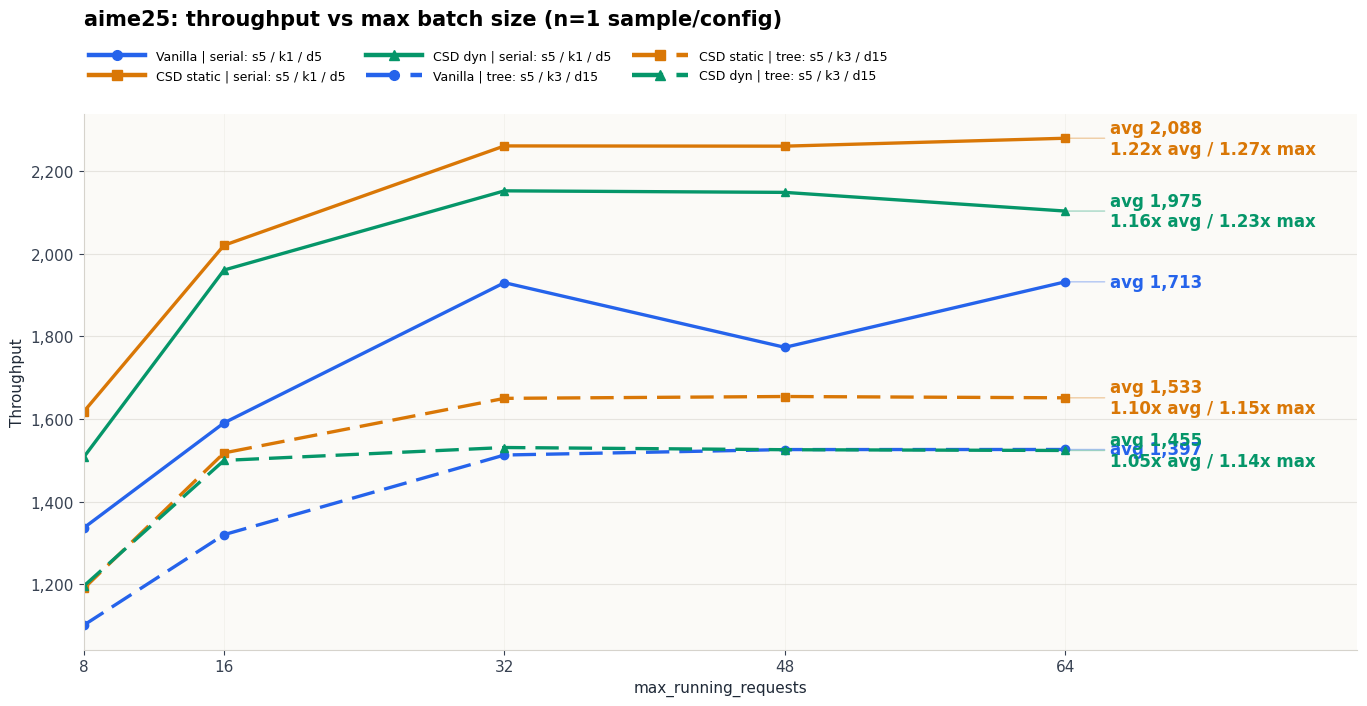

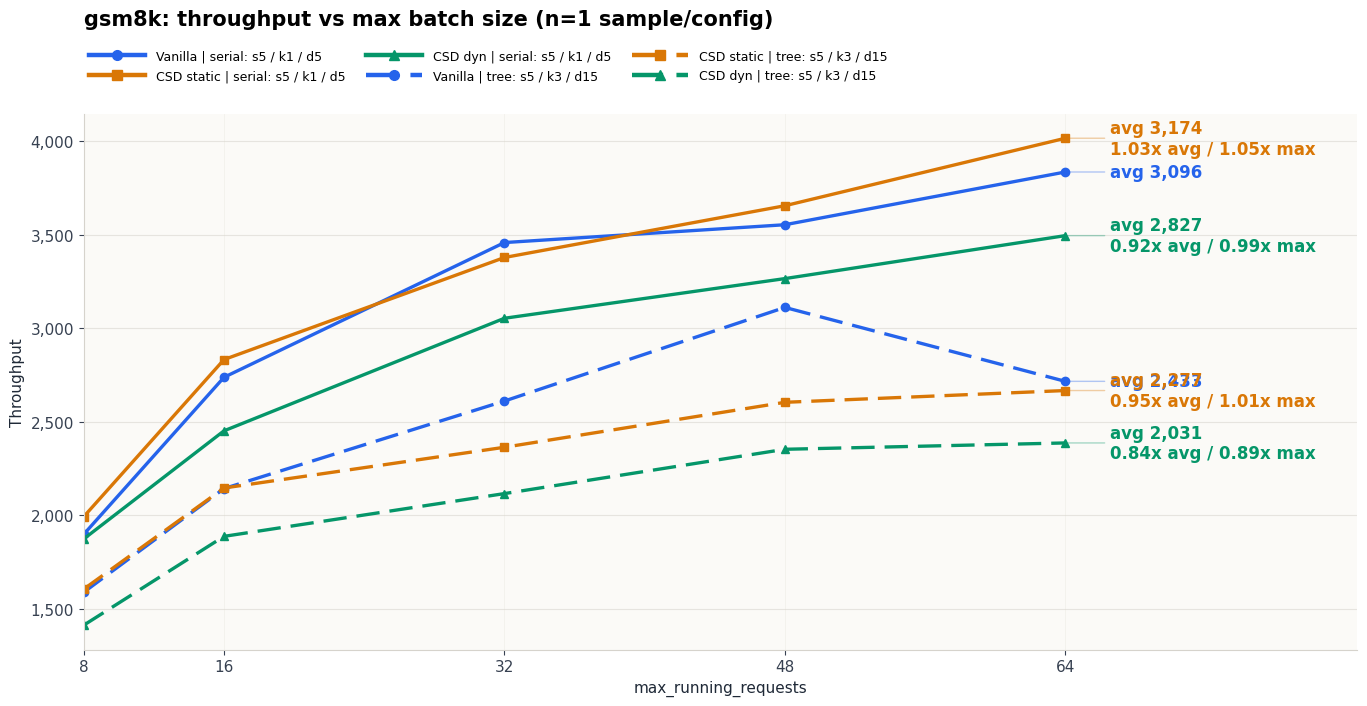

In [18]:
tasks = list(avg_df['base_task'].dropna().unique())
for task in tasks:
    sub = avg_df[avg_df['base_task'] == task].copy()
    fig, ax = plt.subplots(figsize=(13.8, 7.2))

    max_x = sub['max_running_requests'].max()
    label_x = max_x + max(2, max_x * 0.04)
    vanilla_by_shape = {
        spec_shape: group.set_index('max_running_requests')['throughput_mean']
        for spec_shape, group in sub[sub['mode'] == 'vanilla'].groupby('spec_shape')
    }

    for cfg in ordered_configs(sub):
        cfg_df = sub[sub['config_label'] == cfg].sort_values('max_running_requests')
        if cfg_df.empty:
            continue
        color = CONFIG_COLORS.get(cfg, '#6b7280')
        marker = CONFIG_MARKERS.get(cfg, 'o')
        linestyle = CONFIG_LINESTYLES.get(cfg, '-')
        ax.plot(
            cfg_df['max_running_requests'],
            cfg_df['throughput_mean'],
            marker=marker,
            markersize=6,
            linewidth=2.4,
            linestyle=linestyle,
            color=color,
            label=cfg,
        )
        if cfg_df['throughput_std'].gt(0).any():
            ax.fill_between(
                cfg_df['max_running_requests'],
                cfg_df['throughput_mean'] - cfg_df['throughput_std'],
                cfg_df['throughput_mean'] + cfg_df['throughput_std'],
                color=color,
                alpha=0.12,
                linewidth=0,
            )

        mean_throughput = cfg_df['throughput_mean'].mean()
        label = f'avg {mean_throughput:,.0f}'
        cfg_meta = cfg_df.iloc[0]
        if cfg_meta['mode'] == 'csd':
            vanilla_ref = vanilla_by_shape.get(cfg_meta['spec_shape'])
            if vanilla_ref is not None:
                aligned = cfg_df.set_index('max_running_requests')['throughput_mean'].to_frame('csd').join(
                    vanilla_ref.rename('vanilla'),
                    how='inner',
                )
                aligned = aligned[aligned['vanilla'].notna() & aligned['vanilla'].ne(0)]
                if not aligned.empty:
                    speedups = aligned['csd'] / aligned['vanilla']
                    label += f'\n{speedups.mean():.2f}x avg / {speedups.max():.2f}x max'

        ax.annotate(
            label,
            (cfg_df['max_running_requests'].iloc[-1], cfg_df['throughput_mean'].iloc[-1]),
            xytext=(label_x, cfg_df['throughput_mean'].iloc[-1]),
            textcoords='data',
            va='center',
            ha='left',
            fontsize=12,
            fontweight='bold',
            color=color,
            arrowprops=dict(arrowstyle='-', color=color, alpha=0.35, linewidth=1.0),
        )

    ax.set_title(f'{task}: throughput vs max batch size ({sample_title_suffix(sub)})', loc='left', pad=64)
    ax.set_xlabel('max_running_requests')
    ax.set_ylabel('Throughput')
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    ax.set_xticks(sorted(sub['max_running_requests'].unique()))
    ax.set_xlim(sub['max_running_requests'].min(), label_x + max_x * 0.22)
    finish_axis(ax)
    add_readable_legend(ax)
    plt.tight_layout()
    save_current_figure(f'throughput_{safe_filename(task)}')

## Speculative success rate by dataset and max batch size

Each dataset gets one chart. Lines show the averaged `spec_success_rate` for each decoding configuration across `max_running_requests`.

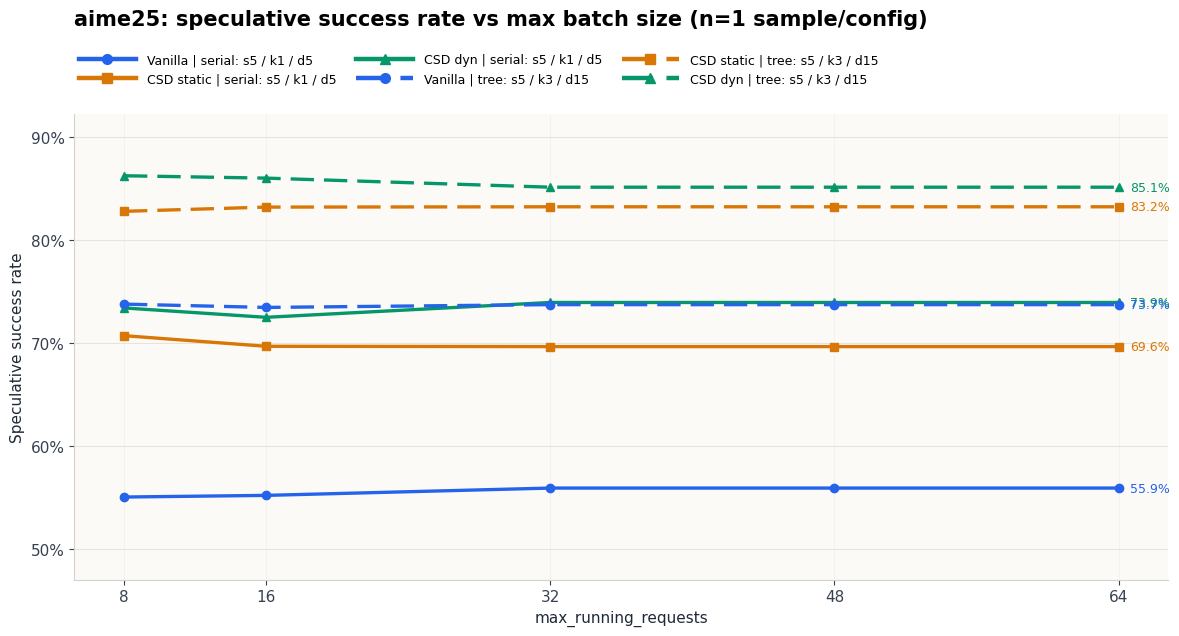

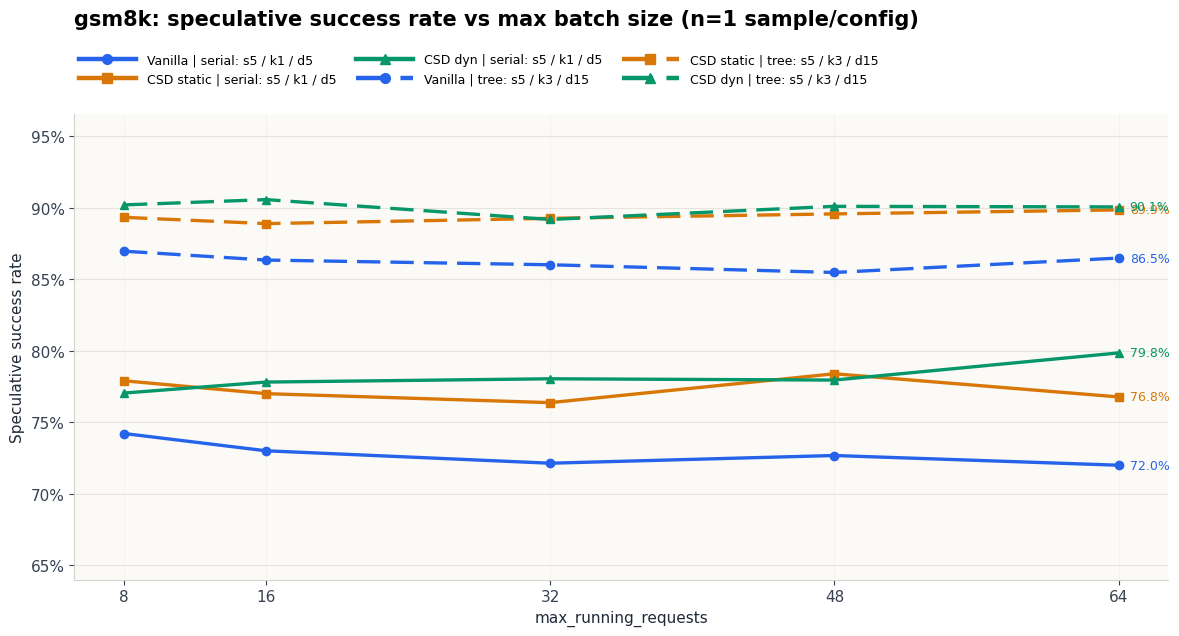

In [19]:
for task in tasks:
    sub = avg_df[avg_df['base_task'] == task].copy()
    fig, ax = plt.subplots(figsize=(12, 6.5))

    for cfg in ordered_configs(sub):
        cfg_df = sub[sub['config_label'] == cfg].sort_values('max_running_requests')
        if cfg_df.empty:
            continue
        color = CONFIG_COLORS.get(cfg, '#6b7280')
        marker = CONFIG_MARKERS.get(cfg, 'o')
        linestyle = CONFIG_LINESTYLES.get(cfg, '-')
        ax.plot(
            cfg_df['max_running_requests'],
            cfg_df['spec_success_rate_mean'],
            marker=marker,
            markersize=6,
            linewidth=2.4,
            linestyle=linestyle,
            color=color,
            label=cfg,
        )
        if cfg_df['spec_success_rate_std'].gt(0).any():
            ax.fill_between(
                cfg_df['max_running_requests'],
                cfg_df['spec_success_rate_mean'] - cfg_df['spec_success_rate_std'],
                cfg_df['spec_success_rate_mean'] + cfg_df['spec_success_rate_std'],
                color=color,
                alpha=0.12,
                linewidth=0,
            )
        annotate_last_point(ax, cfg_df['max_running_requests'], cfg_df['spec_success_rate_mean'], color, percent=True)

    ymin = max(0, sub['spec_success_rate_mean'].min() - 0.08)
    ymax = min(1.02, sub['spec_success_rate_mean'].max() + 0.06)
    ax.set_ylim(ymin, ymax)
    ax.set_title(f'{task}: speculative success rate vs max batch size ({sample_title_suffix(sub)})', loc='left', pad=64)
    ax.set_xlabel('max_running_requests')
    ax.set_ylabel('Speculative success rate')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.set_xticks(sorted(sub['max_running_requests'].unique()))
    finish_axis(ax)
    add_readable_legend(ax)
    plt.tight_layout()
    save_current_figure(f'spec_success_rate_{safe_filename(task)}')

## Accuracy by dataset and max batch size

Each dataset gets one chart. Lines show the averaged task accuracy for each decoding configuration across `max_running_requests`.

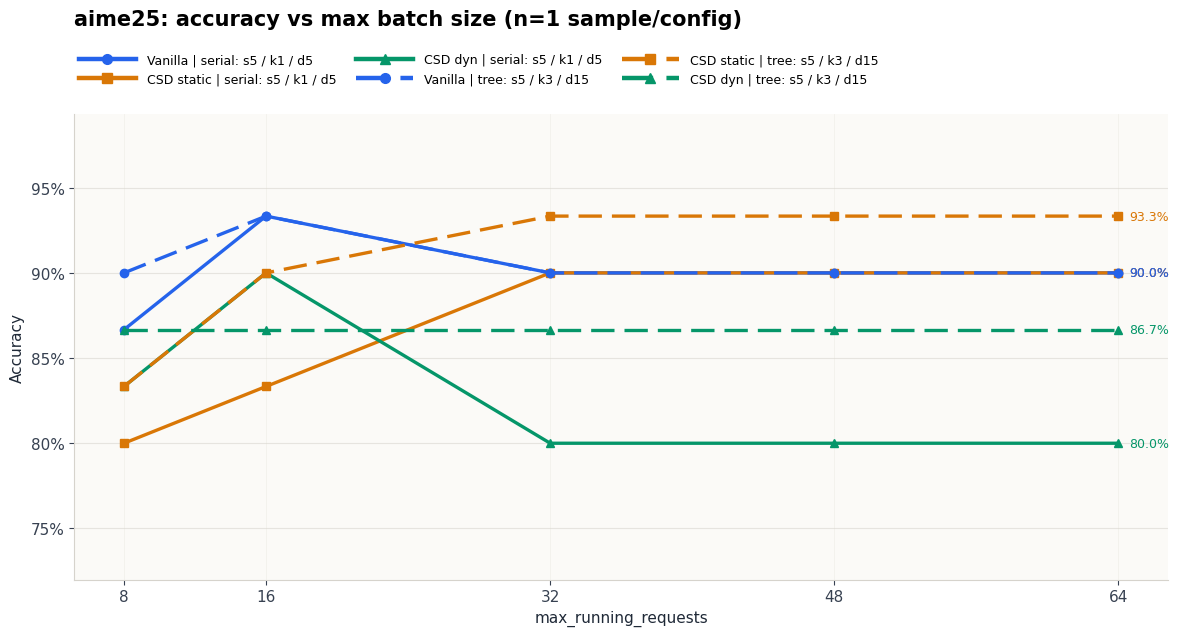

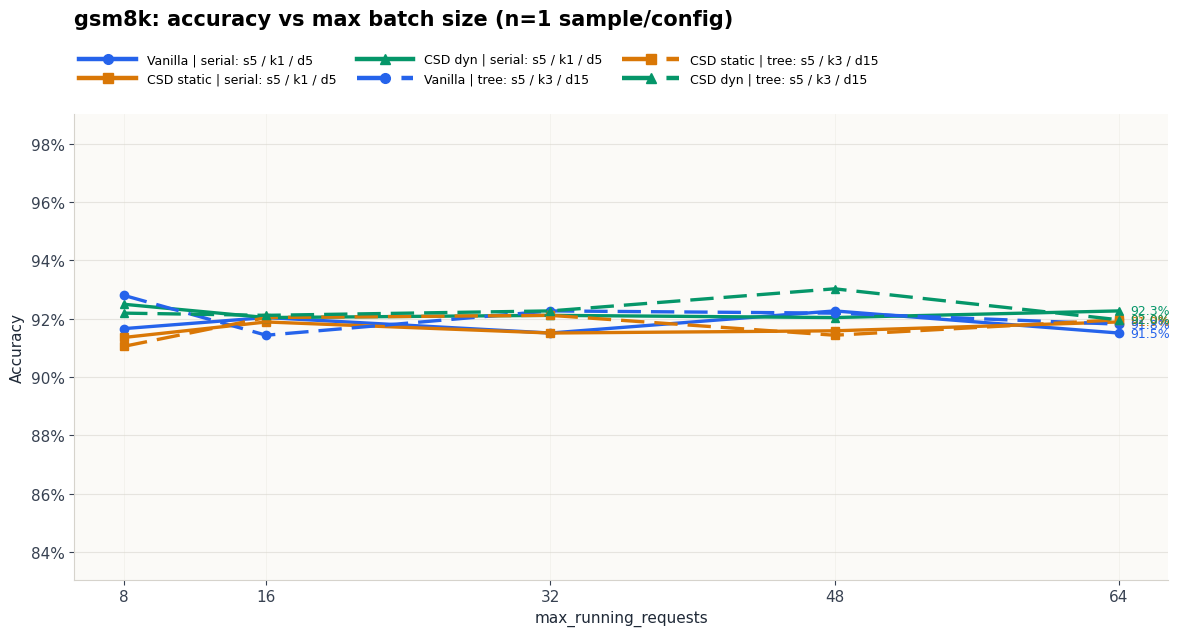

In [20]:
for task in tasks:
    sub = avg_df[avg_df['base_task'] == task].copy()
    fig, ax = plt.subplots(figsize=(12, 6.5))

    for cfg in ordered_configs(sub):
        cfg_df = sub[sub['config_label'] == cfg].sort_values('max_running_requests')
        if cfg_df.empty:
            continue
        color = CONFIG_COLORS.get(cfg, '#6b7280')
        marker = CONFIG_MARKERS.get(cfg, 'o')
        linestyle = CONFIG_LINESTYLES.get(cfg, '-')
        ax.plot(
            cfg_df['max_running_requests'],
            cfg_df['accuracy_mean'],
            marker=marker,
            markersize=6,
            linewidth=2.4,
            linestyle=linestyle,
            color=color,
            label=cfg,
        )
        if cfg_df['accuracy_std'].gt(0).any():
            ax.fill_between(
                cfg_df['max_running_requests'],
                cfg_df['accuracy_mean'] - cfg_df['accuracy_std'],
                cfg_df['accuracy_mean'] + cfg_df['accuracy_std'],
                color=color,
                alpha=0.12,
                linewidth=0,
            )
        annotate_last_point(ax, cfg_df['max_running_requests'], cfg_df['accuracy_mean'], color, percent=True)

    ymin = max(0, sub['accuracy_mean'].min() - 0.08)
    ymax = min(1.02, sub['accuracy_mean'].max() + 0.06)
    ax.set_ylim(ymin, ymax)
    ax.set_title(f'{task}: accuracy vs max batch size ({sample_title_suffix(sub)})', loc='left', pad=64)
    ax.set_xlabel('max_running_requests')
    ax.set_ylabel('Accuracy')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.set_xticks(sorted(sub['max_running_requests'].unique()))
    finish_axis(ax)
    add_readable_legend(ax)
    plt.tight_layout()
    save_current_figure(f'accuracy_{safe_filename(task)}')

## Pivot tables

These tables make it easier to compare configurations at the same `max_running_requests`.

In [21]:
throughput_pivot = avg_df.pivot_table(
    index=['base_task', 'max_running_requests'],
    columns='config_label',
    values='throughput_mean',
    aggfunc='last',
).reset_index()
throughput_pivot.columns.name = None

success_rate_pivot = avg_df.pivot_table(
    index=['base_task', 'max_running_requests'],
    columns='config_label',
    values='spec_success_rate_mean',
    aggfunc='last',
).reset_index()
success_rate_pivot.columns.name = None

accuracy_pivot = avg_df.pivot_table(
    index=['base_task', 'max_running_requests'],
    columns='config_label',
    values='accuracy_mean',
    aggfunc='last',
).reset_index()
accuracy_pivot.columns.name = None

print('Throughput mean')
display(throughput_pivot.style.format({col: '{:.1f}' for col in throughput_pivot.columns if col not in ['base_task', 'max_running_requests']}, na_rep=''))
print('Speculative success-rate mean')
display(success_rate_pivot.style.format({col: '{:.4f}' for col in success_rate_pivot.columns if col not in ['base_task', 'max_running_requests']}, na_rep=''))
print('Accuracy mean')
display(accuracy_pivot.style.format({col: '{:.4f}' for col in accuracy_pivot.columns if col not in ['base_task', 'max_running_requests']}, na_rep=''))

Throughput mean


,base_task,max_running_requests,CSD dyn | serial: s5 / k1 / d5,CSD dyn | tree: s5 / k3 / d15,CSD static | serial: s5 / k1 / d5,CSD static | tree: s5 / k3 / d15,Vanilla | serial: s5 / k1 / d5,Vanilla | tree: s5 / k3 / d15
0,aime25,8,1507.5,1195.0,1617.7,1189.2,1336.1,1100.3
1,aime25,16,1961.0,1499.6,2021.0,1517.8,1590.5,1319.6
2,aime25,32,2153.0,1530.9,2261.9,1650.0,1930.4,1512.7
3,aime25,48,2149.3,1525.6,2261.3,1654.5,1773.7,1525.9
4,aime25,64,2104.0,1523.7,2280.5,1651.4,1932.5,1526.1
5,gsm8k,8,1873.2,1412.2,1992.3,1605.2,1898.2,1588.4
6,gsm8k,16,2451.0,1886.9,2831.8,2145.3,2737.0,2142.3
7,gsm8k,32,3052.5,2115.5,3377.3,2363.1,3457.1,2610.2
8,gsm8k,48,3264.5,2352.3,3653.9,2603.3,3552.4,3110.5
9,gsm8k,64,3494.2,2386.2,4014.7,2666.3,3834.3,2715.4


Speculative success-rate mean


,base_task,max_running_requests,CSD dyn | serial: s5 / k1 / d5,CSD dyn | tree: s5 / k3 / d15,CSD static | serial: s5 / k1 / d5,CSD static | tree: s5 / k3 / d15,Vanilla | serial: s5 / k1 / d5,Vanilla | tree: s5 / k3 / d15
0,aime25,8,0.7339,0.8621,0.7070,0.8276,0.5505,0.7376
1,aime25,16,0.7248,0.8598,0.6967,0.8317,0.5521,0.7344
2,aime25,32,0.7392,0.8510,0.6964,0.8320,0.5592,0.7371
3,aime25,48,0.7392,0.8510,0.6964,0.8320,0.5592,0.7371
4,aime25,64,0.7392,0.8510,0.6964,0.8320,0.5592,0.7371
5,gsm8k,8,0.7704,0.9021,0.7790,0.8934,0.7421,0.8697
6,gsm8k,16,0.7781,0.9058,0.7700,0.8890,0.7300,0.8635
7,gsm8k,32,0.7804,0.8919,0.7637,0.8927,0.7213,0.8602
8,gsm8k,48,0.7795,0.9011,0.7839,0.8958,0.7267,0.8548
9,gsm8k,64,0.7985,0.9007,0.7677,0.8986,0.7199,0.8649


Accuracy mean


,base_task,max_running_requests,CSD dyn | serial: s5 / k1 / d5,CSD dyn | tree: s5 / k3 / d15,CSD static | serial: s5 / k1 / d5,CSD static | tree: s5 / k3 / d15,Vanilla | serial: s5 / k1 / d5,Vanilla | tree: s5 / k3 / d15
0,aime25,8,0.8333,0.8667,0.8000,0.8333,0.8667,0.9000
1,aime25,16,0.9000,0.8667,0.8333,0.9000,0.9333,0.9333
2,aime25,32,0.8000,0.8667,0.9000,0.9333,0.9000,0.9000
3,aime25,48,0.8000,0.8667,0.9000,0.9333,0.9000,0.9000
4,aime25,64,0.8000,0.8667,0.9000,0.9333,0.9000,0.9000
5,gsm8k,8,0.9249,0.9219,0.9136,0.9105,0.9166,0.9280
6,gsm8k,16,0.9204,0.9212,0.9189,0.9204,0.9204,0.9143
7,gsm8k,32,0.9212,0.9227,0.9151,0.9212,0.9151,0.9227
8,gsm8k,48,0.9204,0.9303,0.9158,0.9143,0.9227,0.9219
9,gsm8k,64,0.9227,0.9196,0.9189,0.9196,0.9151,0.9181


## Export summary CSV files

In [22]:
EXPORT_DIR = RESULT_JSONL.parent / 'analysis_tables'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
df.to_csv(EXPORT_DIR / 'flattened_batchsize_sweep.csv', index=False)
script_summary.to_csv(EXPORT_DIR / 'script_derived_sweep_summary.csv', index=False)
avg_df.to_csv(EXPORT_DIR / 'averaged_batchsize_sweep.csv', index=False)
throughput_pivot.to_csv(EXPORT_DIR / 'throughput_by_batchsize.csv', index=False)
success_rate_pivot.to_csv(EXPORT_DIR / 'spec_success_rate_by_batchsize.csv', index=False)
accuracy_pivot.to_csv(EXPORT_DIR / 'accuracy_by_batchsize.csv', index=False)
print(f'Wrote CSV summaries to {EXPORT_DIR}')

Wrote CSV summaries to /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval_batchsize_sweep/20260509_175911/results/analysis_tables
